In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt


### Functions for plotting the function and the gradient descent trajectories

In [2]:
'''
    The following function show the function on a 3D surface plot
'''
def plot_3Dsurface(X,Y,Z,title= "surface plot"):
    # Create figure
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')

    # Surface plot
    surf = ax.plot_surface(
        X, Y, Z,
        cmap='viridis',
        linewidth=0,
        antialiased=True
    )

    # Labels
    ax.set_xlabel('$x$', fontsize=12)
    ax.set_ylabel('$y$', fontsize=12)
    ax.set_zlabel('$f(x,y)$', fontsize=12)
    ax.set_title(title, fontsize=15)

    # Color bar
    cbar = fig.colorbar(surf, shrink=0.6, aspect=12)
    cbar.set_label('Function value')

    # Better viewing angle
    ax.view_init(elev=35, azim=-60)

    plt.tight_layout()
    plt.show()

'''
    The following function show the function on a 2D contour plot
'''
def plot_2Dcontour(X,Y,Z,title= "contour plot"):

    plt.figure(figsize=(6, 4))

    # levels = np.logspace(0, 5, 35)

    contour = plt.contourf(
        X, Y, Z,
        # levels=levels,
        cmap='viridis'
    )

    plt.colorbar(label='Function value')
    plt.contour(
        X, Y, Z,
        # levels=levels,
        colors='k',
        linewidths=0.25,
        alpha=0.4
    )

    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.title(title)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_trajectory_surface(X, Y, Z, trajectory, title="Trajectory of algorithm"):
    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')

    surf = ax.plot_surface(
        X, Y, Z,
        cmap='viridis',
        alpha=0.85,
        linewidth=0
    )

    # Gradient Descent trajectory
    Ztraj = f(trajectory[:,0], trajectory[:,1])

    ax.plot(
        trajectory[:,0],
        trajectory[:,1],
        Ztraj,
        '-o',
        color='red',
        linewidth=3,
        markersize=5,
        label='Gradient Descent'
    )

    # Starting point
    ax.scatter(
        trajectory[0,0],
        trajectory[0,1],
        Ztraj[0],
        color='blue',
        s=70,
        label='Start'
    )

    # Final point
    ax.scatter(
        trajectory[-1,0],
        trajectory[-1,1],
        Ztraj[-1],
        color='black',
        s=70,
        label='End'
    )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x,y)")
    ax.set_title(title)

    fig.colorbar(surf, shrink=0.6)

    ax.view_init(elev=35, azim=-60)
    ax.legend()

    plt.tight_layout()
    plt.show()


def plot_trajectory_contour(X, Y, Z, path, title="Trajectory of algorithm"):
    plt.figure(figsize=(7,5))

    levels = np.logspace(0,5,30)

    plt.contourf(X,Y,Z,
                levels=levels,
                cmap='viridis')

    plt.contour(X,Y,Z,
                levels=levels,
                colors='red',
                linewidths=0.4,
                alpha=0.4)

    # Draw arrows showing each step
    for i in range(len(path)-1):
        plt.annotate(
            "",
            xy=path[i+1],
            xytext=path[i],
            arrowprops=dict(
                arrowstyle="->",
                color="red",
                lw=2
            )
        )

    plt.plot(path[:,0], path[:,1], 'ro', markersize=4)
    plt.plot(path[0,0], path[0,1], 'bs', markersize=9, label='Start')
    plt.plot(path[-1,0], path[-1,1], 'k*', markersize=14, label='End')

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()

    plt.tight_layout()
    plt.show()

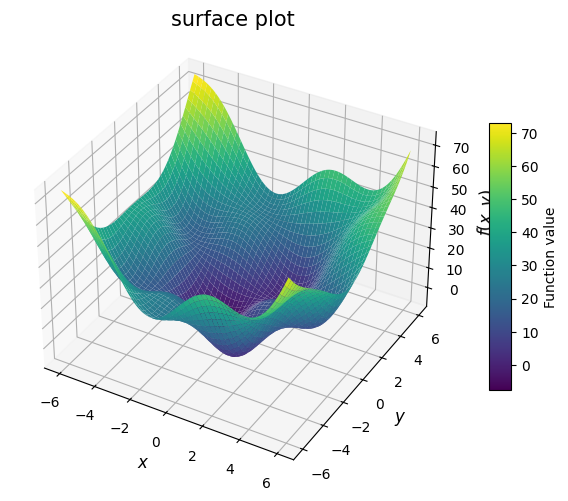

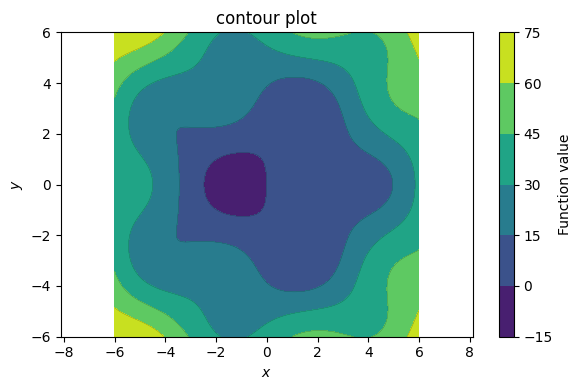

In [3]:
## function definition

def f(x, y):
    return x**2 + y**2 + 10 * np.sin(x) * np.cos(y)

def grad_f(x, y):
    df_dx = 2*x + 10*np.cos(x)*np.cos(y)
    df_dy = 2*y - 10*np.sin(x)*np.sin(y)
    return np.array([df_dx, df_dy])

# Create grid
x = np.linspace(-6, 6, 300)
y = np.linspace(-6, 6, 300)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)


plot_3Dsurface(X,Y,Z)
plot_2Dcontour(X,Y,Z)

### Gradient descent example


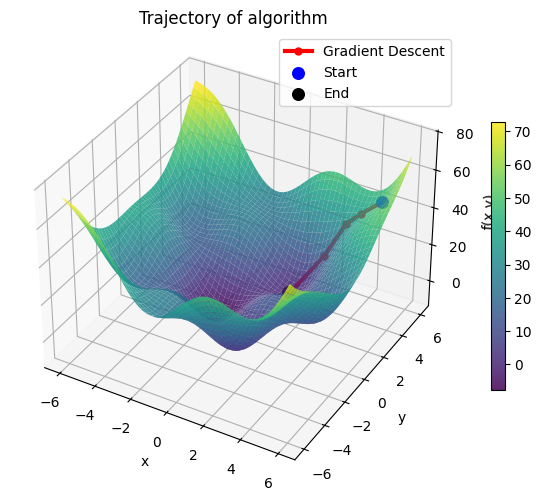

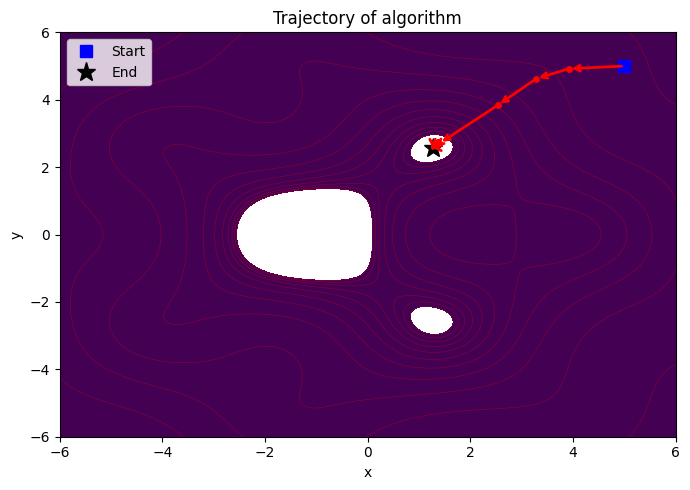

In [4]:

alpha = 0.1
w0 = np.array([5.0, 5.0])
w = w0.copy()
iterations = 100
trajectory = [w.copy()]
for _ in range(iterations):
    grad = grad_f(w[0], w[1])
    w = w - alpha * grad
    trajectory.append(w.copy())
    # print(w)

trajectory = np.array(trajectory)

xgrid = np.linspace(-6,6,400)
ygrid = np.linspace(-6,6,400)
X,Y = np.meshgrid(xgrid,ygrid)
Z = f(X,Y)

plot_trajectory_surface(X, Y, Z, trajectory, title="Trajectory of algorithm")

plot_trajectory_contour(X, Y, Z, trajectory, title="Trajectory of algorithm")

## Algorithms

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(w):
    return 0.5 * np.sum(w**2)

def gradient_f(w):
    return w


## Momentum based gradient descent
def momentum_method(w0, learning_rate, momentum_rate, iterations):
    w = w0.copy()
    v = np.zeros_like(w)
    trajectory = [w.copy()]

    for _ in range(iterations):
        grad = gradient_f(w)
        v = momentum_rate*v - learning_rate*grad
        w += v
        trajectory.append(w.copy())

    return np.array(trajectory)

## Nesterov's accelerated gradient descent
def acceleration_method(w0, learning_rate, momentum_rate, iterations):
    w = w0.copy()
    v = np.zeros_like(w)
    trajectory = [w.copy()]

    for _ in range(iterations):
        y = w + momentum_rate*v
        grad = gradient_f(y)
        v = momentum_rate * v - learning_rate * grad
        w += v
        trajectory.append(w.copy())

    return np.array(trajectory)

## Stochastic Gradient Descent (SGD)
def sgd_method(w0, learning_rate, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    iterations = 100
    for _ in range(iterations):
        grad = gradient_f(w)


        w += learning_rate*grad
        trajectory.append(w.copy())

    return np.array(trajectory)

## Adaptive Gradient (AdaGrad)
def AdaGrad_method(w0, learning_rate, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    g = np.zeros_like(w)
    # grad_square = np.zeros_like(w)

    for _ in range(iterations):
        grad = gradient_f(w)
        grad_square += grad ** 2
        adjusted_lr = learning_rate / (np.sqrt(grad_square) + epsilon)
        w += adjusted_lr * grad
        trajectory.append(w.copy())

    return np.array(trajectory)

## RMSprop algorithm
def RMSprop_method(w0, learning_rate, beta, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    grad_square = np.zeros_like(w)
    #weighted_avg_grad = np.zeros_like(w)

    for _ in range(iterations):
        grad = gradient_f(w)
        grad_square = beta * grad_square + (1-beta) * (grad**2)
        #weighted_avg_grad =
        adjusted_lr = learning_rate / (np.sqrt(grad_square)+ epsilon)
        w += adjusted_lr * grad
        trajectory.append(w.copy())

    return np.array(trajectory)

## Adam optimization algorithm
def Adam_method(w0, learning_rate, beta1, beta2, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    m = np.zeros_like(w)
    v = np.zeros_like(w)
# w0, learning_rate, beta1, beta2, epsilon, iterations
    for t in range(1, iterations + 1):
        grad = gradient_f(w)
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1- beta2) * (grad**2)
        m_hat = m / (1 - beta1** t)
        v_hat = v / (1 - beta2 ** t)
        adjusted_lr = learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
        w += -learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
        trajectory.append(w.copy())

    return np.array(trajectory)


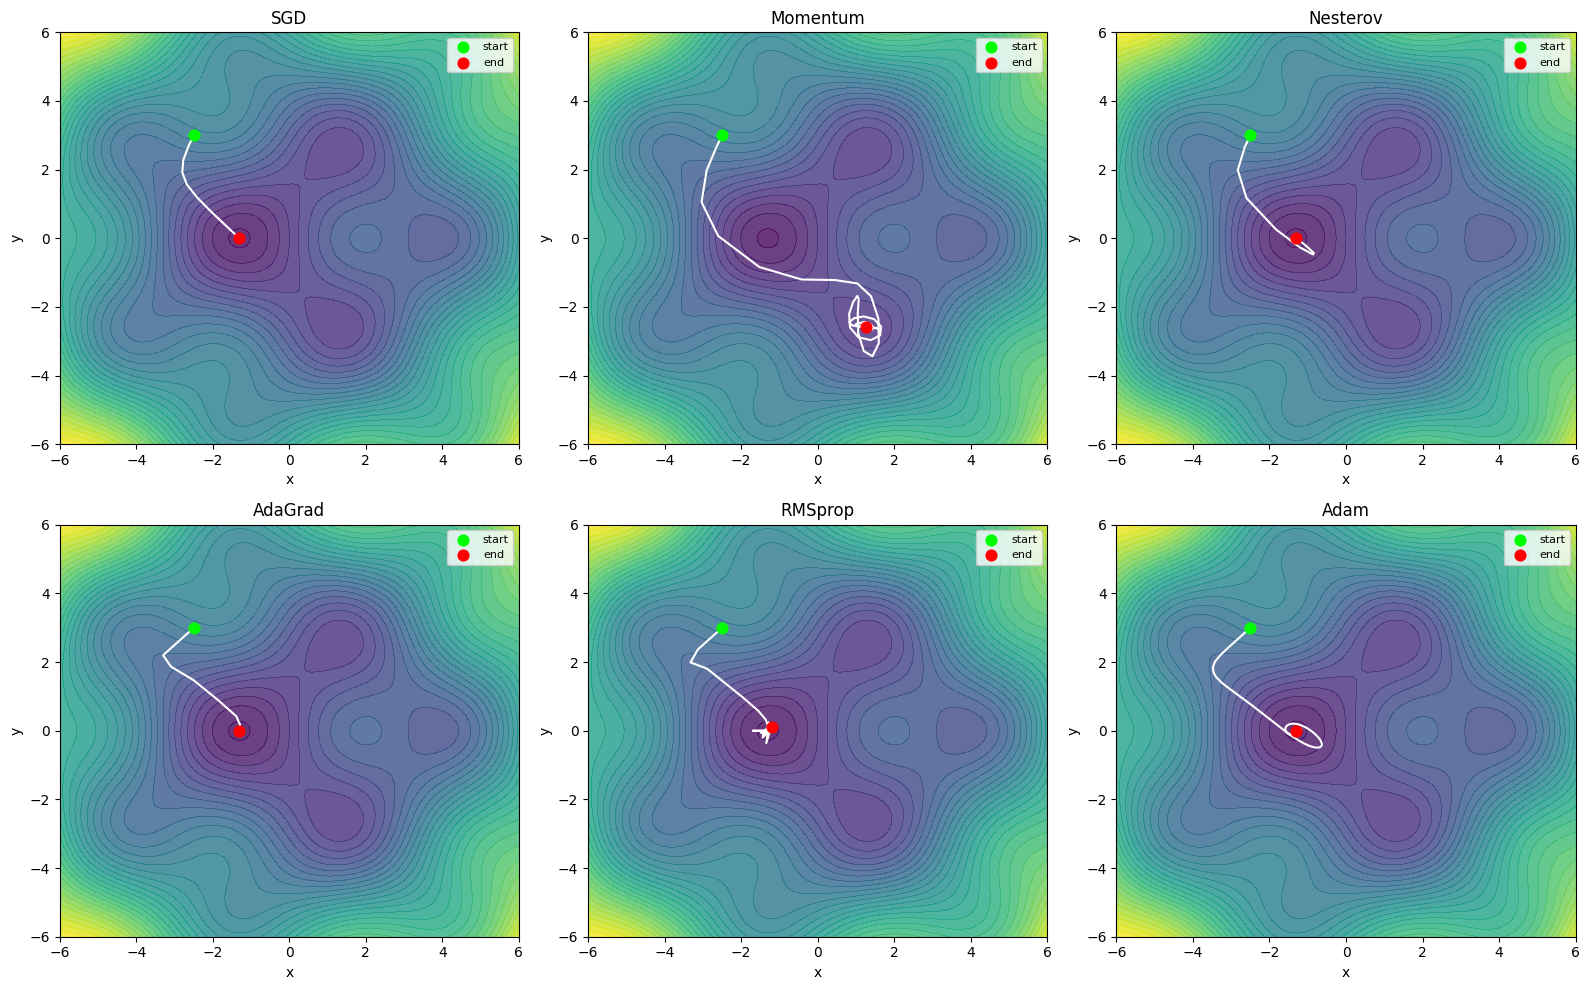

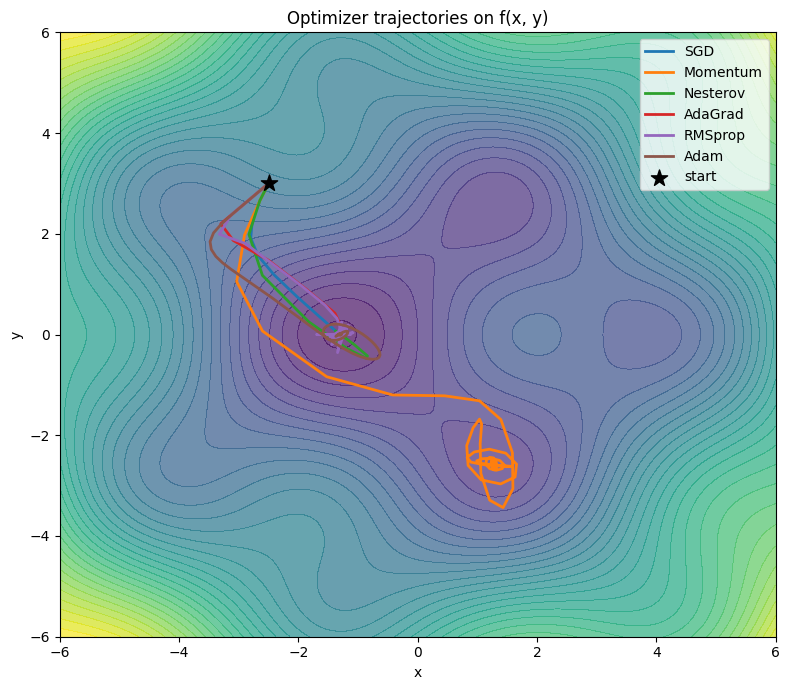

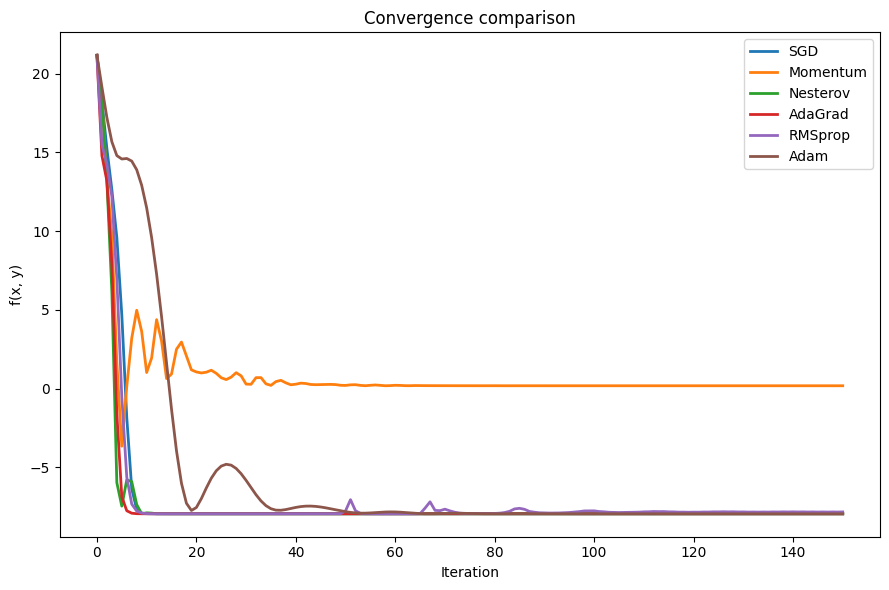

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + y**2 + 10 * np.sin(x) * np.cos(y)

def grad_f(w):
    x, y = w[0], w[1]
    df_dx = 2*x + 10*np.cos(x)*np.cos(y)
    df_dy = 2*y - 10*np.sin(x)*np.sin(y)
    return np.array([df_dx, df_dy])

## Momentum based gradient descent
def momentum_method(w0, learning_rate, momentum_rate, iterations):
    w = w0.copy()
    v = np.zeros_like(w)
    trajectory = [w.copy()]
    for _ in range(iterations):
        grad = grad_f(w)
        v = momentum_rate*v - learning_rate*grad
        w += v
        trajectory.append(w.copy())
    return np.array(trajectory)

## Nesterov's accelerated gradient descent
def acceleration_method(w0, learning_rate, momentum_rate, iterations):
    w = w0.copy()
    v = np.zeros_like(w)
    trajectory = [w.copy()]
    for _ in range(iterations):
        y = w + momentum_rate*v          # look-ahead point
        grad = grad_f(y)                 # gradient evaluated at look-ahead
        v = momentum_rate*v - learning_rate*grad
        w += v
        trajectory.append(w.copy())
    return np.array(trajectory)

## Stochastic Gradient Descent (SGD)
def sgd_method(w0, learning_rate, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    for _ in range(iterations):
        grad = grad_f(w)
        w += -learning_rate * grad
        trajectory.append(w.copy())
    return np.array(trajectory)

## Adaptive Gradient (AdaGrad)
def AdaGrad_method(w0, learning_rate, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    grad_square = np.zeros_like(w)
    for _ in range(iterations):
        grad = grad_f(w)
        grad_square += grad**2
        adjusted_lr = learning_rate / (np.sqrt(grad_square) + epsilon)
        w += -adjusted_lr * grad
        trajectory.append(w.copy())
    return np.array(trajectory)

## RMSprop algorithm
def RMSprop_method(w0, learning_rate, beta, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    grad_square = np.zeros_like(w)
    for _ in range(iterations):
        grad = grad_f(w)
        grad_square = beta*grad_square + (1 - beta)*grad**2   # EMA of squared grads
        adjusted_lr = learning_rate / (np.sqrt(grad_square) + epsilon)
        w += -adjusted_lr * grad
        trajectory.append(w.copy())
    return np.array(trajectory)

## Adam optimization algorithm
def Adam_method(w0, learning_rate, beta1, beta2, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    for t in range(1, iterations + 1):
        grad = grad_f(w)
        m = beta1*m + (1 - beta1)*grad
        v = beta2*v + (1 - beta2)*grad**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        adjusted_lr = learning_rate / (np.sqrt(v_hat) + epsilon)
        w += -adjusted_lr * m_hat
        trajectory.append(w.copy())
    return np.array(trajectory)

# ---- Run all methods from the same start ----
w0 = np.array([-2.5, 3.0])
iterations = 150

results = {
    "SGD":      sgd_method(w0, learning_rate=0.05, iterations=iterations),
    "Momentum": momentum_method(w0, learning_rate=0.05, momentum_rate=0.9, iterations=iterations),
    "Nesterov": acceleration_method(w0, learning_rate=0.05, momentum_rate=0.9, iterations=iterations),
    "AdaGrad":  AdaGrad_method(w0, learning_rate=0.8, epsilon=1e-8, iterations=iterations),
    "RMSprop":  RMSprop_method(w0, learning_rate=0.2, beta=0.9, epsilon=1e-8, iterations=iterations),
    "Adam":     Adam_method(w0, learning_rate=0.2, beta1=0.9, beta2=0.999, epsilon=1e-8, iterations=iterations),
}

x_range = np.linspace(-6, 6, 400)
y_range = np.linspace(-6, 6, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)
colors = plt.cm.tab10.colors

# 1) One contour subplot per method
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (name, traj) in zip(axes.flat, results.items()):
    ax.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.8)
    ax.plot(traj[:, 0], traj[:, 1], color="white", linewidth=1.5)
    ax.scatter(*traj[0], color="lime", s=60, zorder=5, label="start")
    ax.scatter(*traj[-1], color="red", s=60, zorder=5, label="end")
    ax.set_title(name)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 2) All trajectories overlaid on one contour
plt.figure(figsize=(8, 7))
plt.contourf(X, Y, Z, levels=40, cmap="viridis", alpha=0.7)
for (name, traj), color in zip(results.items(), colors):
    plt.plot(traj[:, 0], traj[:, 1], label=name, color=color, linewidth=2)
plt.scatter(*w0, color="black", marker="*", s=150, label="start", zorder=5)
plt.title("Optimizer trajectories on f(x, y)")
plt.xlabel("x"); plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Convergence: f(w) vs iteration
plt.figure(figsize=(9, 6))
for (name, traj), color in zip(results.items(), colors):
    f_vals = f(traj[:, 0], traj[:, 1])
    plt.plot(f_vals, label=name, color=color, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("f(x, y)")
plt.title("Convergence comparison")
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# Define the simpler function for surface plotting (takes two 2D arrays x and y)
def f_quadratic_plot_surface(x_coords, y_coords):
    return 0.5 * (x_coords**2 + y_coords**2)

# Create grid for the quadratic function visualization
x_quad = np.linspace(-5, 5, 100)
y_quad = np.linspace(-5, 5, 100)
X_quad, Y_quad = np.meshgrid(x_quad, y_quad)
Z_quad = f_quadratic_plot_surface(X_quad, Y_quad)

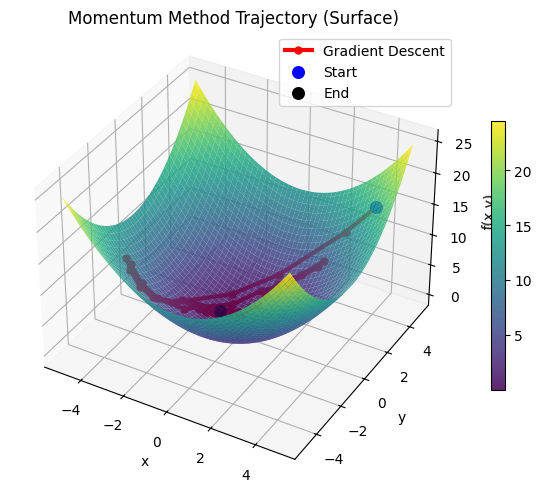

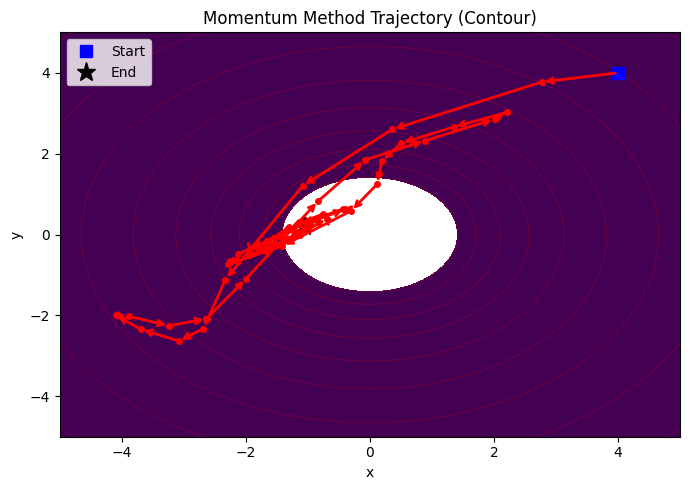

In [24]:
w0_momentum = np.array([4.0, 4.0])
learning_rate_momentum = 0.1
momentum_rate_momentum = 0.9
iterations_momentum = 50

trajectory_momentum = momentum_method(
    w0_momentum,
    learning_rate_momentum,
    momentum_rate_momentum,
    iterations_momentum
)

# Temporarily redefine global f and grad_f for plotting
global f
global grad_f
original_f = f
original_grad_f = grad_f
f = f_quadratic_plot_surface # Use the new plotting surface function
grad_f = gradient_f # Use the global gradient_f from cell a283d44f

plot_trajectory_surface(X_quad, Y_quad, Z_quad, trajectory_momentum, title="Momentum Method Trajectory (Surface)")
plot_trajectory_contour(X_quad, Y_quad, Z_quad, trajectory_momentum, title="Momentum Method Trajectory (Contour)")

# Restore original f and grad_f
f = original_f
grad_f = original_grad_f

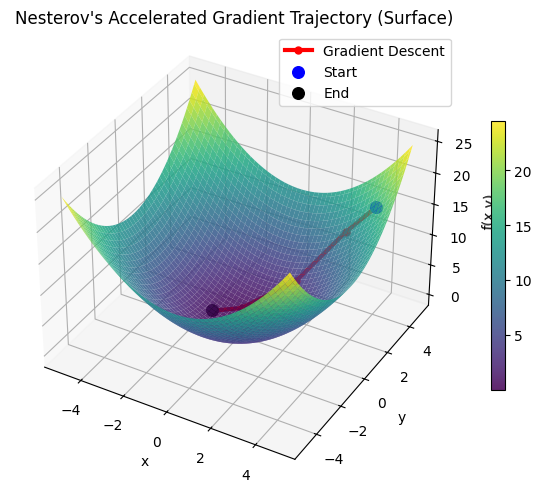

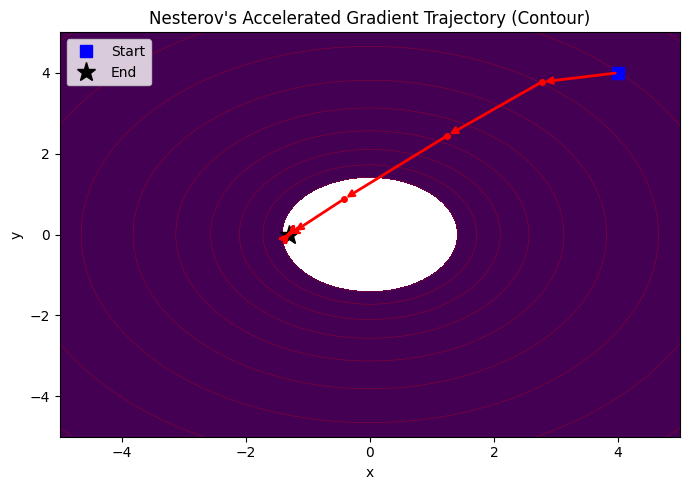

In [25]:
w0_nesterov = np.array([4.0, 4.0])
learning_rate_nesterov = 0.1
momentum_rate_nesterov = 0.9
iterations_nesterov = 50

trajectory_nesterov = acceleration_method(
    w0_nesterov,
    learning_rate_nesterov,
    momentum_rate_nesterov,
    iterations_nesterov
)

# Temporarily redefine global f and grad_f for plotting
global f
global grad_f
original_f = f
original_grad_f = grad_f
f = f_quadratic_plot_surface # Use the new plotting surface function
grad_f = gradient_f # Use the global gradient_f from cell a283d44f

plot_trajectory_surface(X_quad, Y_quad, Z_quad, trajectory_nesterov, title="Nesterov's Accelerated Gradient Trajectory (Surface)")
plot_trajectory_contour(X_quad, Y_quad, Z_quad, trajectory_nesterov, title="Nesterov's Accelerated Gradient Trajectory (Contour)")

# Restore original f and grad_f
f = original_f
grad_f = original_grad_f

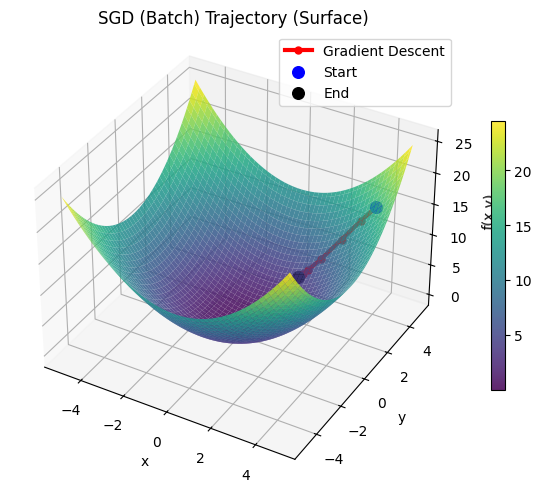

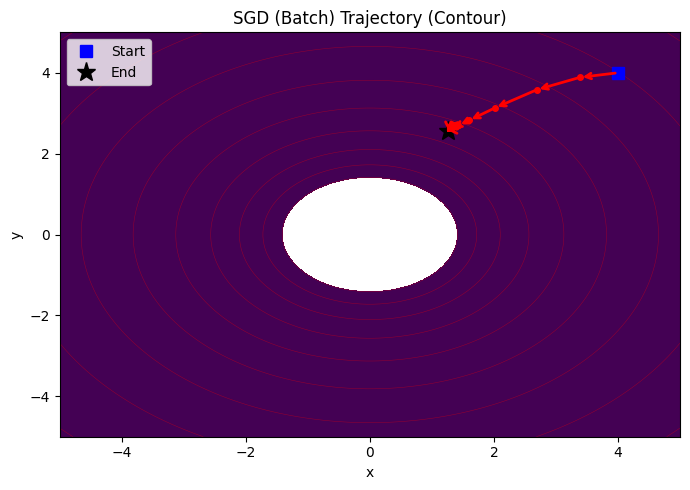

In [26]:
w0_sgd = np.array([4.0, 4.0])
learning_rate_sgd = 0.05
iterations_sgd = 100

trajectory_sgd = sgd_method(
    w0_sgd,
    learning_rate_sgd,
    iterations_sgd
)

# Temporarily redefine global f and grad_f for plotting
global f
global grad_f
original_f = f
original_grad_f = grad_f
f = f_quadratic_plot_surface # Use the new plotting surface function
grad_f = gradient_f # Use the global gradient_f from cell a283d44f

plot_trajectory_surface(X_quad, Y_quad, Z_quad, trajectory_sgd, title="SGD (Batch) Trajectory (Surface)")
plot_trajectory_contour(X_quad, Y_quad, Z_quad, trajectory_sgd, title="SGD (Batch) Trajectory (Contour)")

# Restore original f and grad_f
f = original_f
grad_f = original_grad_f

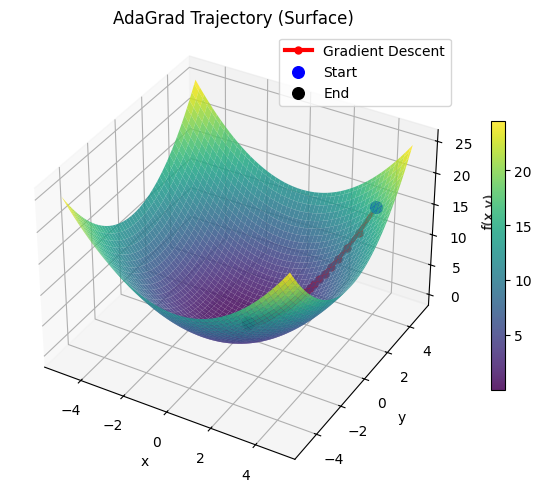

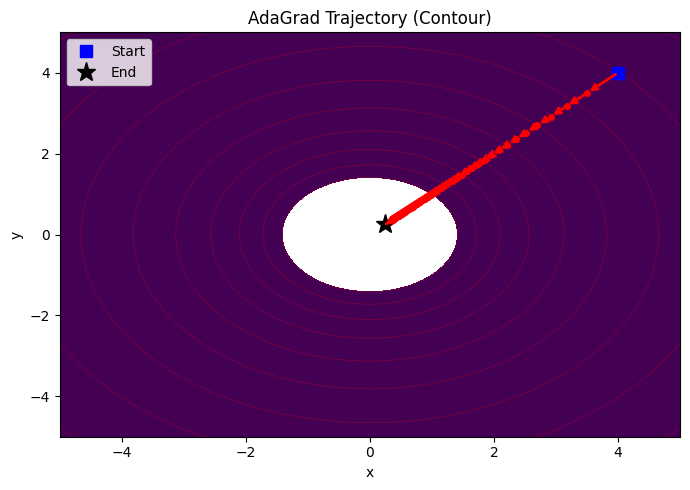

In [27]:
w0_adagrad = np.array([4.0, 4.0])
learning_rate_adagrad = 0.5
epsilon_adagrad = 1e-8
iterations_adagrad = 50

# Corrected AdaGrad_method for execution
def AdaGrad_method_corrected(w0, learning_rate, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    grad_square_sum = np.zeros_like(w) # Initialize grad_square_sum

    for _ in range(iterations):
        grad = gradient_f(w) # Use the global gradient_f from cell a283d44f
        grad_square_sum += grad ** 2
        adjusted_lr = learning_rate / (np.sqrt(grad_square_sum) + epsilon)
        w -= adjusted_lr * grad # Corrected update rule (should be subtraction for minimization)
        trajectory.append(w.copy())

    return np.array(trajectory)

trajectory_adagrad = AdaGrad_method_corrected(
    w0_adagrad,
    learning_rate_adagrad,
    epsilon_adagrad,
    iterations_adagrad
)

# Temporarily redefine global f and grad_f for plotting
global f
global grad_f
original_f = f
original_grad_f = grad_f
f = f_quadratic_plot_surface # Use the new plotting surface function
grad_f = gradient_f # Use the global gradient_f from cell a283d44f

plot_trajectory_surface(X_quad, Y_quad, Z_quad, trajectory_adagrad, title="AdaGrad Trajectory (Surface)")
plot_trajectory_contour(X_quad, Y_quad, Z_quad, trajectory_adagrad, title="AdaGrad Trajectory (Contour)")

# Restore original f and grad_f
f = original_f
grad_f = original_grad_f

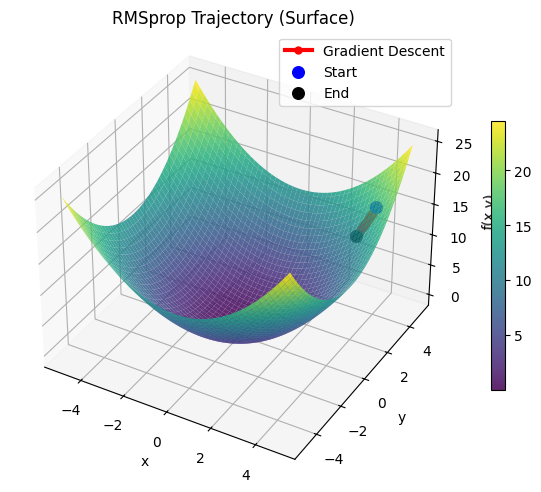

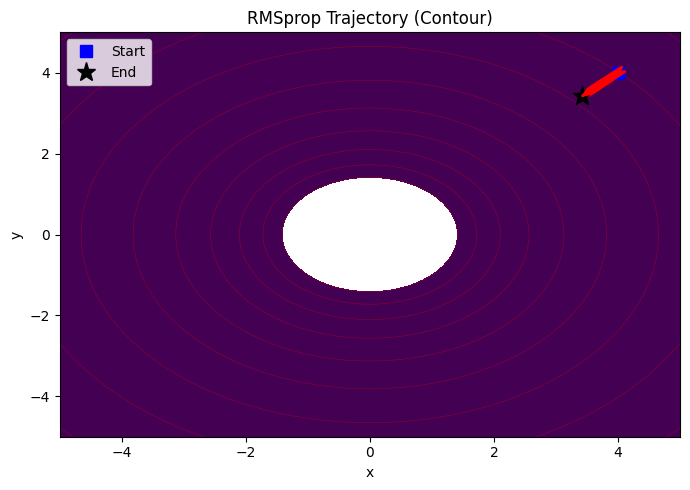

In [28]:
w0_rmsprop = np.array([4.0, 4.0])
learning_rate_rmsprop = 0.01
beta_rmsprop = 0.9
epsilon_rmsprop = 1e-8
iterations_rmsprop = 50

# Corrected RMSprop_method for execution
def RMSprop_method_corrected(w0, learning_rate, beta, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    grad_square_avg = np.zeros_like(w) # Initialize weighted average of squared gradients

    for _ in range(iterations):
        grad = gradient_f(w) # Use the global gradient_f from cell a283d44f
        grad_square_avg = beta * grad_square_avg + (1 - beta) * (grad**2)
        adjusted_lr = learning_rate / (np.sqrt(grad_square_avg) + epsilon)
        w -= adjusted_lr * grad # Corrected update rule (should be subtraction for minimization)
        trajectory.append(w.copy())

    return np.array(trajectory)

trajectory_rmsprop = RMSprop_method_corrected(
    w0_rmsprop,
    learning_rate_rmsprop,
    beta_rmsprop,
    epsilon_rmsprop,
    iterations_rmsprop
)

# Temporarily redefine global f and grad_f for plotting
global f
global grad_f
original_f = f
original_grad_f = grad_f
f = f_quadratic_plot_surface # Use the new plotting surface function
grad_f = gradient_f # Use the global gradient_f from cell a283d44f

plot_trajectory_surface(X_quad, Y_quad, Z_quad, trajectory_rmsprop, title="RMSprop Trajectory (Surface)")
plot_trajectory_contour(X_quad, Y_quad, Z_quad, trajectory_rmsprop, title="RMSprop Trajectory (Contour)")

# Restore original f and grad_f
f = original_f
grad_f = original_grad_f

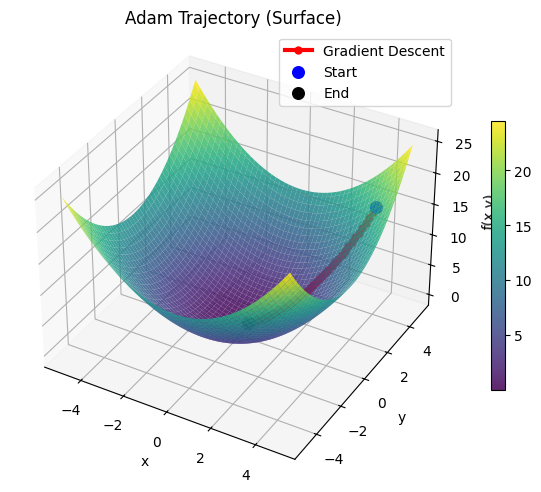

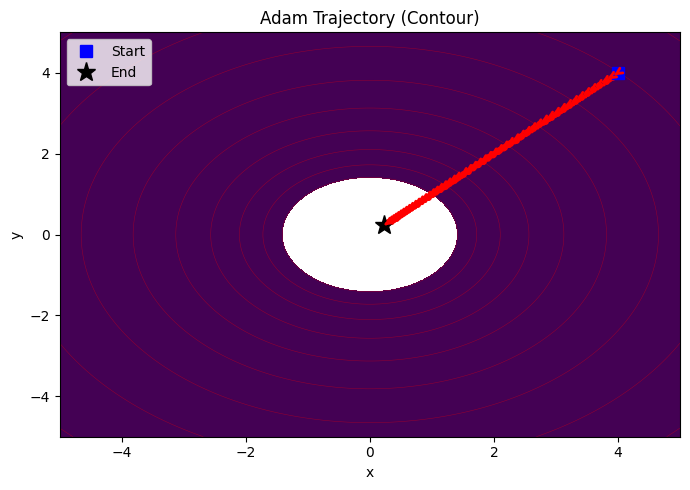

In [29]:
w0_adam = np.array([4.0, 4.0])
learning_rate_adam = 0.1
beta1_adam = 0.9
beta2_adam = 0.999
epsilon_adam = 1e-8
iterations_adam = 50

# Corrected Adam_method for execution
def Adam_method_corrected(w0, learning_rate, beta1, beta2, epsilon, iterations):
    w = w0.copy()
    trajectory = [w.copy()]
    m = np.zeros_like(w)
    v = np.zeros_like(w)

    for t in range(1, iterations + 1):
        grad = gradient_f(w) # Use the global gradient_f from cell a283d44f
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * (grad**2)
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        # Corrected update rule
        w -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
        trajectory.append(w.copy())

    return np.array(trajectory)

trajectory_adam = Adam_method_corrected(
    w0_adam,
    learning_rate_adam,
    beta1_adam,
    beta2_adam,
    epsilon_adam,
    iterations_adam
)

# Temporarily redefine global f and grad_f for plotting
global f
global grad_f
original_f = f
original_grad_f = grad_f
f = f_quadratic_plot_surface # Use the new plotting surface function
grad_f = gradient_f # Use the global gradient_f from cell a283d44f

plot_trajectory_surface(X_quad, Y_quad, Z_quad, trajectory_adam, title="Adam Trajectory (Surface)")
plot_trajectory_contour(X_quad, Y_quad, Z_quad, trajectory_adam, title="Adam Trajectory (Contour)")

# Restore original f and grad_f
f = original_f
grad_f = original_grad_f